In [52]:
import seaborn as sns
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [53]:
result_path = Path("../results/downstream_task")
# methods_list = ["uniform","psa", "kmm", "mrs-forest", "fw-mrs-temperature",  "fw-mrs-temperature-svm", "soft-mrs-linear", "soft-mrs-exponential"]
methods_list = ["fw-mrs-temperature",  "fw-mrs-temperature-svm",]
# bias_types = ["less_negative_class", "less_positive_class", "mean_difference"]
bias_types = ["less_positive_class"]
# less_bias_strengths = ["0.1", "0.2", "0.3"]
less_bias_strengths = ["0.1"]
mean_bias_strengthts = ["0.8", "0.9"]
datasets = ["folktables_employment", "folktables_income", "hr_analytics", "breast_cancer", "loan_prediction"]

## Plot per temperature

In [54]:
dropped_samples = []
dict_list = {}
for dataset in datasets:
    for bias_type in bias_types:
        for method in methods_list:
            if bias_type == "mean_difference":
                bias_strengths = mean_bias_strengthts
            else : 
                bias_strengths = less_bias_strengths
            for bias_strength in bias_strengths:
                json_file = result_path / dataset / bias_type /  bias_strength/ method / "dropped_elements.json"
                result_file = pd.read_json(str(json_file), orient="table", typ="values")
                dict_list[method] = result_file

result_df = pd.DataFrame(data=dict_list).T

In [55]:
result_df

,0.1_mean,0.1_std,0.05_mean,0.05_std,0.01_mean,0.01_std,0.005_mean,0.005_std
fw-mrs-temperature,4.22,3.694807,3.14,3.328723,0.52,0.964158,0.14,0.529528
fw-mrs-temperature-svm,2.22,3.008588,0.74,1.277654,0.04,0.195959,0.02,0.140000


## Plot per method

In [56]:
methods_list = ["fw-mrs-temperature",  "fw-mrs-temperature-svm", "mrs-forest"]
aurocs = []
auprcs = []
dict_list = []
for dataset in datasets:
    for bias_type in bias_types:
        for method in methods_list:
            if bias_type == "mean_difference":
                bias_strengths = mean_bias_strengthts
            else : 
                bias_strengths = less_bias_strengths
            for bias_strength in bias_strengths:
                json_file = result_path / dataset / bias_type /  bias_strength/ method / "classification_results/dropped_samples.json"
                result_file = pd.read_json(str(json_file), typ="series")
                dict_list.append(
                    {
                        "Dropped Samples": result_file,
                        "Data Set": dataset,
                        "Method": method,
                        "bias_type": bias_type,
                        "bias_strength": bias_strength,
                    }
                                )
result_df = pd.DataFrame(data=dict_list)
result_df = result_df.explode(column="Dropped Samples", ignore_index=True)
result_df = result_df.replace({"fw-mrs-temperature": "FW-MRS-RF", "mrs-forest": "MRS", "fw-mrs-temperature-svm": "FW-MRS-SVM"})
result_df = result_df.replace({"folktables_employment": "Employment", "folktables_income": "Income",
                               "breast_cancer": "Breast Cancer", "hr_analytics": "HR Analytic", "loan_prediction": "Loan"})

In [57]:
result_df["Dropped Samples"] = result_df["Dropped Samples"].astype(float)
result_df.loc[result_df["Data Set"] == "Employment", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Employment", "Dropped Samples"] / 1408)
result_df.loc[result_df["Data Set"] == "Income", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Income", "Dropped Samples"] / 1448)
result_df.loc[result_df["Data Set"] == "HR Analytic", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "HR Analytic", "Dropped Samples"] / 3048)
result_df.loc[result_df["Data Set"] == "Breast Cancer", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Breast Cancer", "Dropped Samples"] / 113)
result_df.loc[result_df["Data Set"] == "Loan", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Loan", "Dropped Samples"] / 72)

result_df

,Dropped Samples,Data Set,Method,bias_type,bias_strength
0,0.319602,Employment,FW-MRS-RF,less_positive_class,0.1
1,0.099432,Employment,FW-MRS-RF,less_positive_class,0.1
2,0.106534,Employment,FW-MRS-RF,less_positive_class,0.1
3,0.074574,Employment,FW-MRS-RF,less_positive_class,0.1
4,0.102983,Employment,FW-MRS-RF,less_positive_class,0.1
...,...,...,...,...,...
610,0.027778,Loan,MRS,less_positive_class,0.1
611,0.166667,Loan,MRS,less_positive_class,0.1
612,0.097222,Loan,MRS,less_positive_class,0.1
613,0.180556,Loan,MRS,less_positive_class,0.1


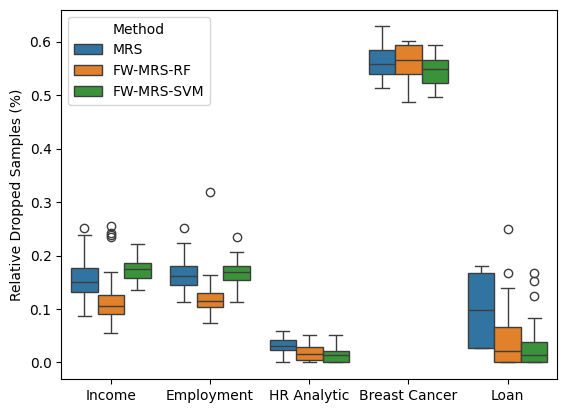

In [58]:
sns.boxplot(data=result_df, y="Dropped Samples", x="Data Set", hue="Method",
            order=["Income", "Employment", "HR Analytic", "Breast Cancer", "Loan"],
            hue_order=["MRS","FW-MRS-RF", "FW-MRS-SVM"]).set(xlabel=None, ylabel="Relative Dropped Samples (%)")
plt.savefig("relative_dropped_samples_per_method.pdf", bbox_inches="tight")